In [ ]:
#import h5py         # To read 'LVIS' waveform data
import numpy as np
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
from tqdm import tqdm
import random

Load the dataframe containing pre-processed LVIS waveforms and ALS canopy profiles:

In [2]:
LVIS_df = pd.read_pickle('./LVISF_SERC/clipped_wf_df')
AOP_df = pd.read_pickle('./clipped_AOP_columns_XY/AOP_7m_binned_15cm_veg_df')
LVIS_df

,Shotnumber,RX_waveform_clipped,Peaks,ZT_m,ZH_m,ZG_m,Signal_End_m,ZT,ZH,ZG,Signal_End
0,98011926,"[[925, 148], [926, 149], [927, 149], [928, 149...",939,2.083,0.473,0.473,-2.372437,925.29709,936.030423,936.030423,955
1,98011927,"[[927, 147], [928, 147], [929, 148], [930, 148...","[929, 942]",2.163,0.513,0.513,-2.787573,927.996178,938.996178,938.996178,961
2,98011929,"[[926, 146], [927, 145], [928, 144], [929, 144...",940,2.133,0.483,0.483,-2.465894,926.34071,937.34071,937.34071,957
3,98011930,"[[928, 149], [929, 149], [930, 147], [931, 146...",943,2.183,0.543,0.543,-2.344415,928.817231,939.750565,939.750565,959
4,98011932,"[[927, 146], [928, 146], [929, 147], [930, 147...",941,2.123,0.513,0.513,-2.284329,927.617805,938.351139,938.351139,957
...,...,...,...,...,...,...,...,...,...,...,...
207331,98241599,"[[920, 149], [921, 149], [922, 148], [923, 147...","[937, 964]",49.373,47.503,47.503,42.113226,920.601509,933.068175,933.068175,969
207332,98241600,"[[917, 157], [918, 162], [919, 165], [920, 164...","[919, 935, 966, 978]",49.163,47.143,47.143,39.426257,917.088382,930.555049,930.555049,982
207333,98241602,"[[922, 146], [923, 143], [924, 141], [925, 142...",939,48.893,46.993,46.993,42.808545,922.436966,935.103633,935.103633,963
207334,98241605,"[[920, 147], [921, 149], [922, 150], [923, 150...",937,47.903,46.043,46.043,42.467578,920.763854,933.163854,933.163854,957


Visualize bare-ground waveforms selected from QGIS:

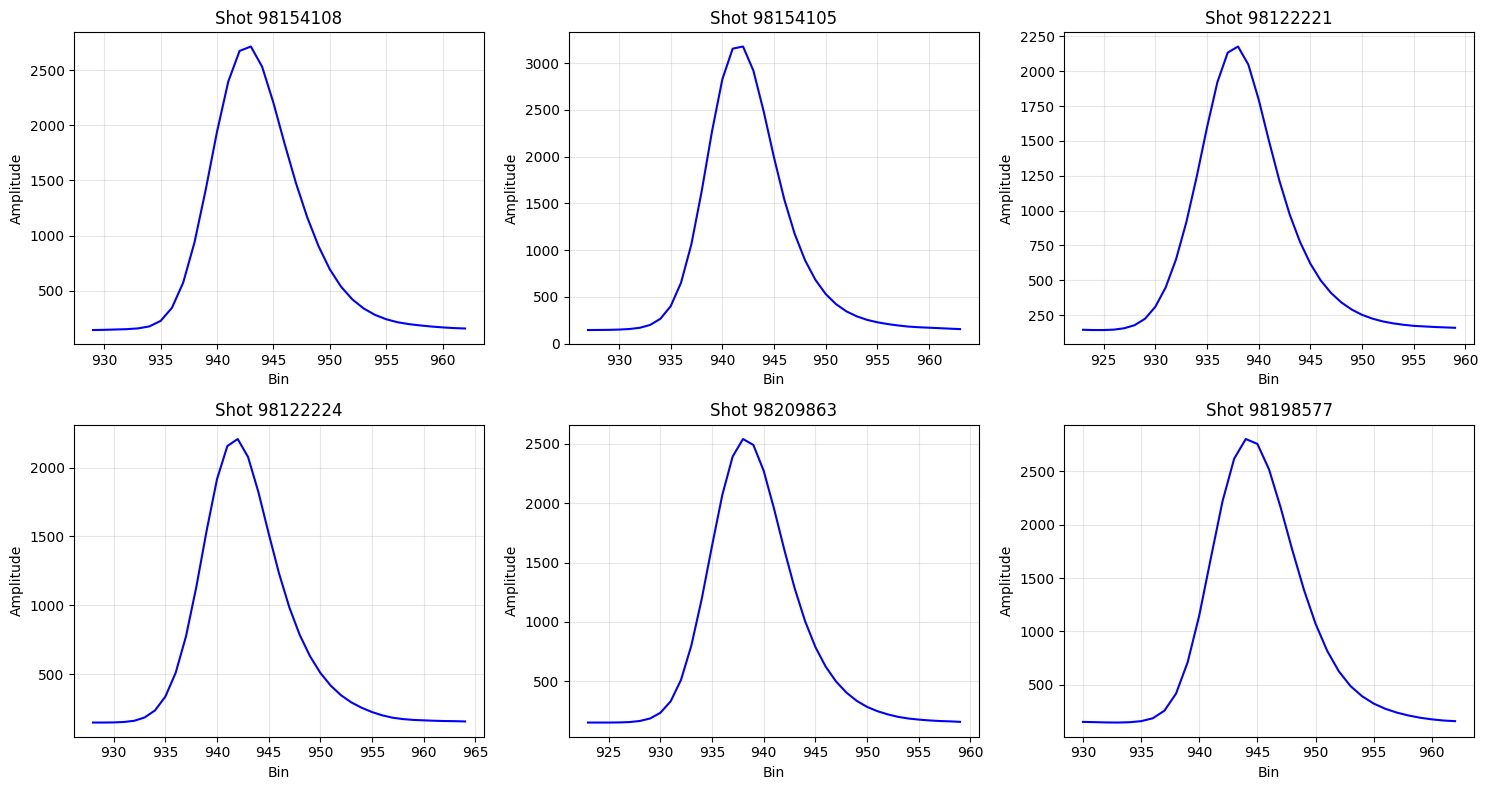

In [3]:
## B. To perform waveform deconvolution, import pure/bare ground return from the waveform;
## From "Qgis" we can see that the bare ground return have following shot number:

gnd_waveforms_shotnums = [98154108, 98154105, 98122221, 98122224, 98209863, 98198577]
extracted_rx_waveforms = []

# Plot RX_waveform_clipped for each shot number
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, shot_num in enumerate(gnd_waveforms_shotnums):
    # Find the row in LVIS_df matching this shot number
    row = LVIS_df[LVIS_df['Shotnumber'] == shot_num]
    
    if not row.empty:
        waveform_data = row['RX_waveform_clipped'].values[0]
        waveform_array = np.array(waveform_data)
        extracted_rx_waveforms.append(waveform_array)
        
        # Plot time bins vs amplitude
        axes[idx].plot(waveform_array[:, 0], waveform_array[:, 1], color='b', linewidth=1.5)
        axes[idx].set_title(f'Shot {shot_num}')
        axes[idx].set_xlabel('Bin')
        axes[idx].set_ylabel('Amplitude')
        axes[idx].grid(True, alpha=0.3)
    else:
        axes[idx].text(0.5, 0.5, f'Shot {shot_num}\nNot found', 
                      ha='center', va='center', transform=axes[idx].transAxes)
        axes[idx].set_title(f'Shot {shot_num}')

plt.tight_layout()
plt.show()

Compute average bare ground waveform as system response:

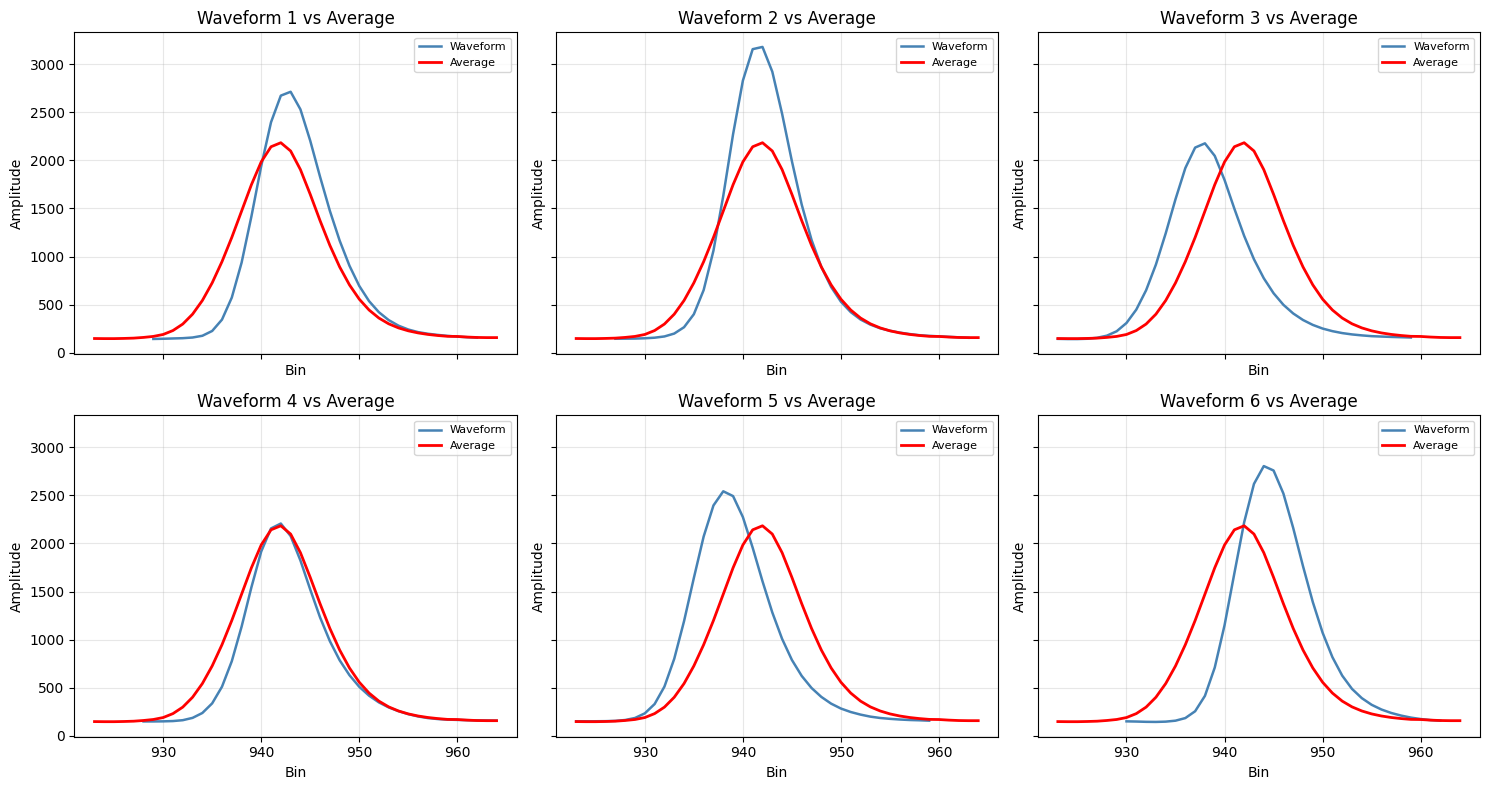

In [4]:
# Compute average bare-ground waveform from the 6 extracted waveforms
series_list = []
for wf in extracted_rx_waveforms:
    wf = np.asarray(wf, dtype=float)
    s = pd.Series(wf[:, 1], index=wf[:, 0].astype(int))
    series_list.append(s)

aligned = pd.concat(series_list, axis=1)
avg_series = aligned.mean(axis=1, skipna=True).sort_index()

# Final average waveform as [bin, amplitude]
avg_bare_ground_rx = np.column_stack((avg_series.index.values, avg_series.values))

# Plot each waveform against the average waveform
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, wf in enumerate(extracted_rx_waveforms):
    wf = np.asarray(wf, dtype=float)
    axes[i].plot(wf[:, 0], wf[:, 1], color='steelblue', lw=1.8, label='Waveform')
    axes[i].plot(avg_bare_ground_rx[:, 0], avg_bare_ground_rx[:, 1], color='red', lw=2.0, label='Average')
    axes[i].set_title(f'Waveform {i+1} vs Average')
    axes[i].set_xlabel('Bin')
    axes[i].set_ylabel('Amplitude')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

Load waveforms in test split onto lists:

In [ ]:
import sys
sys.path.append('./lvis2als')
from data import create_data_splits
from training import TrainingConfig

In [6]:
# Load filtered LVIS_wf_list to a pickle file
with open('./LVIS_wf_below80_noground.pkl', 'rb') as f:
    LVIS_wf_list = pickle.load(f)

# Load filtered AOP_wf_list to a pickle file
with open('./AOP_wf_below80_noground.pkl', 'rb') as f:
    AOP_wf_list = pickle.load(f)

print(f"LVIS_wf_list loaded: {len(LVIS_wf_list)} waveforms")
print(f"AOP_wf_list loaded: {len(AOP_wf_list)} waveforms")

LVIS_wf_list loaded: 101110 waveforms
AOP_wf_list loaded: 101110 waveforms


In [8]:
# Configure training
config = TrainingConfig(

    num_workers=0,  # Adjust based on your system
    # Model architecture
    embed_dim=256,
    use_auxiliary_features=True,
    use_cls_token=False,
    als_query_fusion="Add",
    encoder_layers=6,
    decoder_layers=6,
    num_heads=8,
    ffn_dim=1024,
    dropout=0.1,
    
    # Your data statistics
    lvis_height_range=(-15.0, 82.0),
    als_height_range=(1.0, 80.0),
    height_resolution=0.15,
    global_max_count=4094.0,
    global_max_sum=80684.0,
    
    # Loss weights (tune based on validation)
    lambda_count=1.2,    # Count accuracy in data region
    lambda_zero_penalty=0.8,  # Zero prediction outside data region
    lambda_shape=0.4,         # Waveform shape similarity
    
    # Training parameters
    batch_size=32,
    learning_rate=1e-4,
    num_epochs=100,
    scheduler="cosine",
    warmup_epochs=5,
    early_stopping_patience=15,
    
    # Data
    train_split=0.8,
    val_split=0.1,
    augment_train=False,
    boundary_buffer=2.0,
)

In [9]:
# Create data loaders
train_loader, val_loader, test_loader = create_data_splits(
    LVIS_wf_list, AOP_wf_list, config
)

print(f"test_loader batches: {len(test_loader)}")

# Load LVIS and AOP waveforms from test_loader dataset
LVIS_wf_test = test_loader.dataset.lvis_waveforms
print(len(LVIS_wf_test))
AOP_wf_test = test_loader.dataset.als_waveforms
print(len(AOP_wf_test))

# Plot 5 random waveform pairs from filtered LVIS and AOP lists
print(f"Plotting {n_pairs} random waveform pairs from test set...")
n_pairs = min(5, len(LVIS_wf_test), len(AOP_wf_test))
pair_indices = random.sample(range(min(len(LVIS_wf_test), len(AOP_wf_test))), n_pairs)

fig, axs = plt.subplots(n_pairs, 2, figsize=(12, 3 * n_pairs), constrained_layout=True)

if n_pairs == 1:
    axs = np.array([axs])

for r, idx in enumerate(pair_indices):
    lvis_wf = np.asarray(LVIS_wf_test[idx])
    aop_wf = np.asarray(AOP_wf_test[idx])

    # LVIS
    ax_lvis = axs[r, 0]
    if lvis_wf.size > 0 and lvis_wf.ndim == 2:
        ax_lvis.plot(lvis_wf[:, 1], lvis_wf[:, 0], color='C0', lw=1)
    else:
        ax_lvis.text(0.5, 0.5, 'Empty LVIS waveform', ha='center', va='center')
    ax_lvis.set_title(f'LVIS idx {idx}')
    ax_lvis.set_xlabel('Counts')
    ax_lvis.set_ylabel('Height (m)')

    # AOP
    ax_aop = axs[r, 1]
    if aop_wf.size > 0 and aop_wf.ndim == 2:
        ax_aop.plot(aop_wf[:, 1], aop_wf[:, 0], color='C1', lw=1)
    else:
        ax_aop.text(0.5, 0.5, 'Empty AOP waveform', ha='center', va='center')
    ax_aop.set_title(f'AOP idx {idx}')
    ax_aop.set_xlabel('Hits')
    ax_aop.set_ylabel('Height (m)')

plt.show()
print('Plotted pair indices:', pair_indices)

Data splits: train=80888, val=10111, test=10111
test_loader batches: 316
10111
10111


NameError: name 'n_pairs' is not defined

Apply Gold deconvolution to waveforms in test split:

In [10]:
## E. One-Fold Gold-Deconvolution Algorithm:
#  To extract deconvolved waveform on the waveforms contained in the test split 
# using "smoothed_avg_bare_ground_rx" as system contribution / system response term and save it in "processed_deconvolved_gold" array.

# Helper function to manually shift the deconvolved signal to correct for alignment
def manual_shift(signal, shift):
    """Manually shift a 1D signal."""
    return np.roll(signal, shift)

# Construct the Response matrix (H) for convolution
def response_matrix(h, len_x):
    """Creates a Response matrix from the filter h for convolution."""
    len_h = len(h)
    H = np.zeros((len_x + len_h - 1, len_x))
    for i in range(len_x): 
        H[i:i + len_h, i] = h
    return H

# Define Boosted one fold gold deconvolution algorithm
def boosted_gold_deconvolution(P_t, R_t, num_iterations=10, num_repetitions=5, boosting_coefficient=1.25, positivity=True):
    y = P_t
    
    # Pad y dynamically so its length perfectly matches H.T's expected dimensions
    target_len = len(P_t) + len(R_t) - 1
    pad_total = target_len - len(P_t)
    pad_left = pad_total // 2
    pad_right = pad_total - pad_left
    y_padded = np.pad(y, (pad_left, pad_right), mode='constant')
    
    # Create matrix H from R_t
    H = response_matrix(R_t, len(P_t))
    
    # Calculate y' = H^T y
    y_prime = H.T @ y_padded
    H_T_H = H.T @ H

    # Initial value of P_delta 
    P_delta = np.ones_like(P_t)

    # Repeat for each repetition
    for r in range(num_repetitions):
        # Repeat for 'n' iterations
        for i in range(num_iterations):
            # Added a tiny epsilon (1e-10) to the denominator to prevent division by zero warnings
            denominator = H_T_H @ P_delta
            denominator[denominator == 0] = 1e-10 
            
            P_delta_est = y_prime / denominator 
            P_delta_new = P_delta_est * P_delta
            P_delta = P_delta_new
            
            # Enforce positivity constraint if enabled
            if positivity:
                P_delta = np.maximum(P_delta, 0)

        if r < num_repetitions - 1:
            P_delta = np.power(P_delta, boosting_coefficient)

    # Energy-based post-scaling to match the original signal energy
    def apply_energy_scaling(P_delta_t_est, P_t):
        energy_P_t = np.sum(np.abs(P_t) ** 2)
        energy_P_delta_t_est = np.sum(np.abs(P_delta_t_est) ** 2)
        scale_factor = np.sqrt(energy_P_t / energy_P_delta_t_est) if energy_P_delta_t_est > 0 else 1.0
        return P_delta_t_est * scale_factor

    # Apply energy-based post-scaling
    P_delta_scaled = apply_energy_scaling(P_delta, P_t)
    
    # Cross-correlation to estimate the shift between P(t) and deconvolved P_delta
    cross_corr = np.correlate(P_t, P_delta_scaled, mode='full')
    shift_index = np.argmax(cross_corr) - len(P_t) + 1
    
    # Apply manual shift to correct alignment using np.roll
    P_delta_shifted = manual_shift(P_delta_scaled, shift=shift_index)
    
    return P_delta_shifted


# Execute
deconvolved_gold = []

print("\nStarting Gold Deconvolution...")
for i, wf in tqdm(enumerate(LVIS_wf_test), total=len(LVIS_wf_test)):
    # Running the deconvolution with boosting_coefficient=1 i.e. no boosting
    deconv_wave = boosted_gold_deconvolution(
        P_t=wf[:, 1], 
        R_t=avg_bare_ground_rx[:, 1], 
        num_iterations=500,      
        num_repetitions=1, 
        boosting_coefficient=1, 
        positivity=True
    )
    deconvolved_gold.append(deconv_wave)


Starting Gold Deconvolution...


100%|██████████| 10111/10111 [00:46<00:00, 216.10it/s]


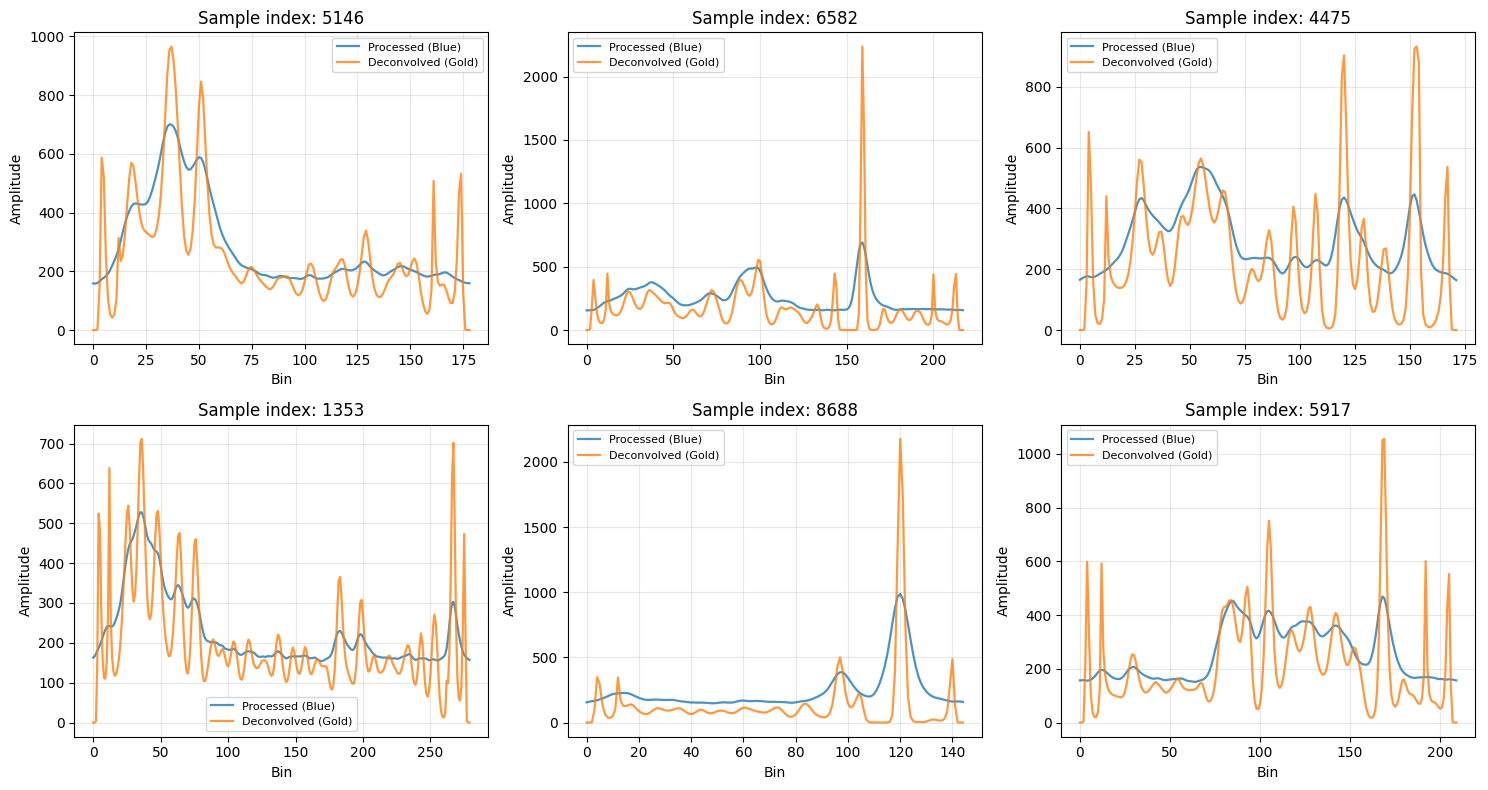

In [103]:
# Plot 6 random test waveforms overlaid with corresponding Gold-deconvolved waveforms

n_plot = 6
n_available = min(len(LVIS_wf_test), len(deconvolved_gold))
#random_indices = np.random.choice(n_available, size=n_plot, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=False, sharey=False)
axes = axes.flatten()

for ax, idx in zip(axes, random_indices):
    proc_wf = LVIS_wf_test[idx][:, 1]  # waveform counts
    deconv_wf = np.asarray(deconvolved_gold[idx], dtype=float)

    # Handle any length mismatch safely
    m = min(len(proc_wf), len(deconv_wf))
    x = np.arange(m)

    ax.plot(x, proc_wf[:m], color="tab:blue", lw=1.6, alpha=0.8, label="Processed (Blue)")
    ax.plot(x, deconv_wf[:m], color="tab:orange", lw=1.6, alpha=0.8, label="Deconvolved (Gold)")
    ax.set_title(f"Sample index: {idx}")
    ax.set_xlabel("Bin")
    ax.set_ylabel("Amplitude")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

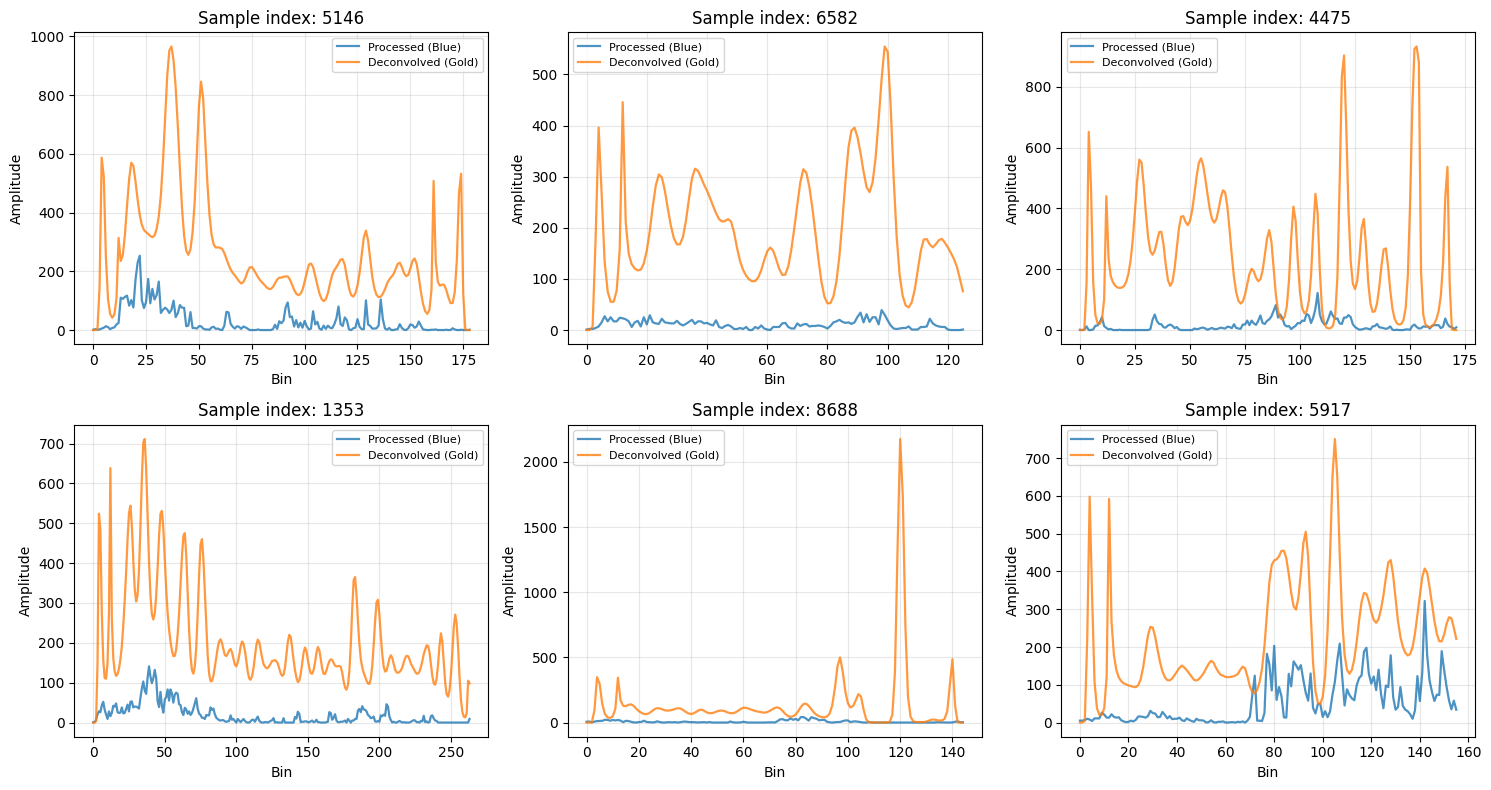

In [ ]:
# Plot 6 random AOP waveforms from the test set overlaid with corresponding Gold-deconvolved waveforms 

n_plot = len(random_indices)
ncols = 3
nrows = int(np.ceil(n_plot / ncols))

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=False, sharey=False)
axes = axes.flatten()

for ax, idx in zip(axes, random_indices):
    proc_wf = AOP_wf_test[idx][:, 1]  # waveform counts
    deconv_wf = np.asarray(deconvolved_gold[idx], dtype=float)

    # Handle any length mismatch safely
    m = min(len(proc_wf), len(deconv_wf))
    x = np.arange(m)

    ax.plot(x, proc_wf[:m], color="tab:blue", lw=1.6, alpha=0.8, label="Processed (Blue)")
    ax.plot(x, deconv_wf[:m], color="tab:orange", lw=1.6, alpha=0.8, label="Deconvolved (Gold)")
    ax.set_title(f"Sample index: {idx}")
    ax.set_xlabel("Bin")
    ax.set_ylabel("Amplitude")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

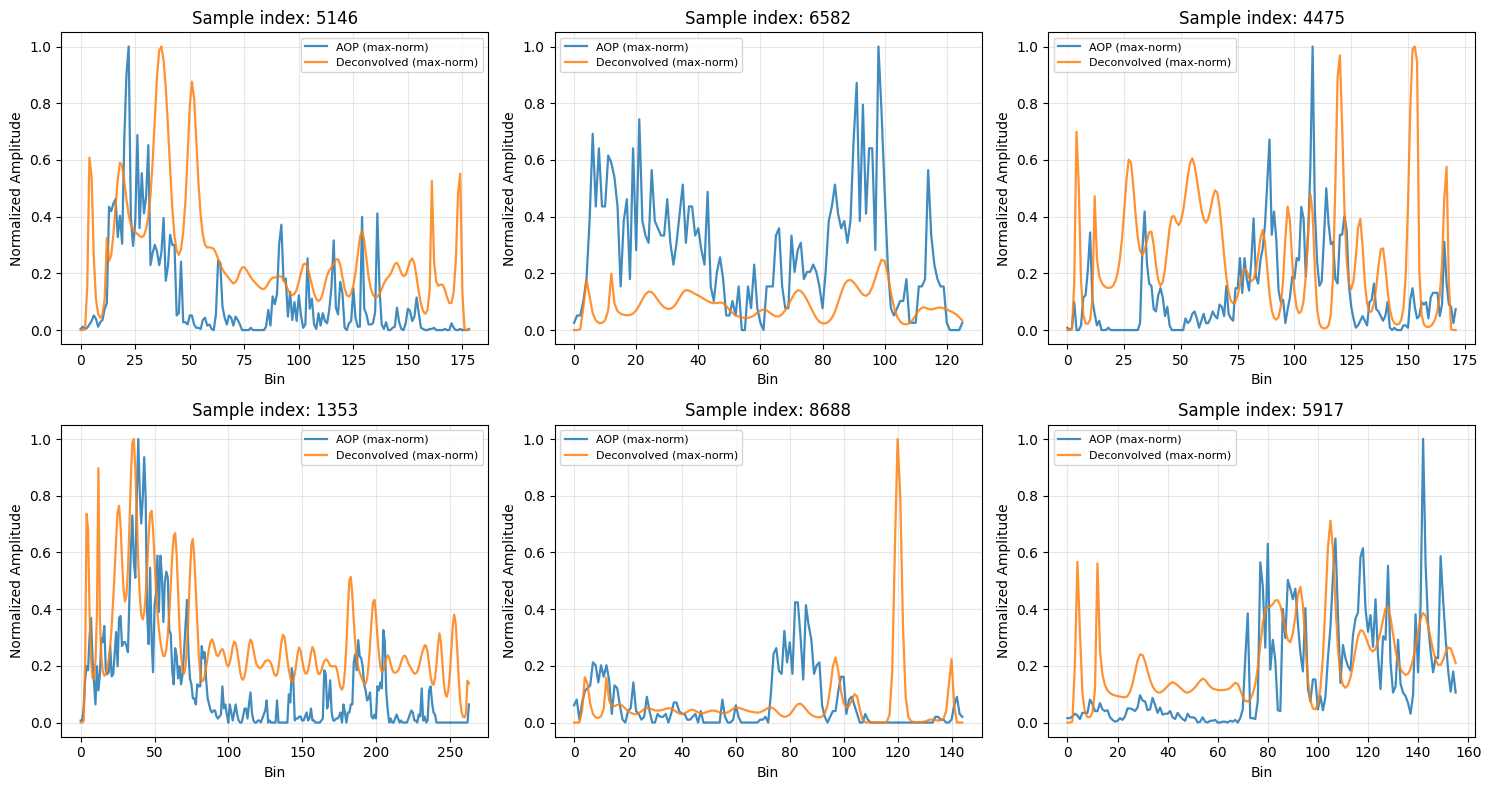

In [106]:
# Max-normalize AOP_wf_list and deconvolved_gold for selected random_indices, then plot

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=False, sharey=False)
axes = axes.flatten()

for ax, idx in zip(axes, random_indices):
    aop_wf = np.asarray(AOP_wf_test[idx][:, 1], dtype=float)
    deconv_wf = np.asarray(deconvolved_gold[idx], dtype=float)

    # Max-normalization (safe)
    aop_max = np.max(np.abs(aop_wf)) if aop_wf.size else 0.0
    deconv_max = np.max(np.abs(deconv_wf)) if deconv_wf.size else 0.0
    aop_norm = aop_wf / aop_max if aop_max > 0 else aop_wf
    deconv_norm = deconv_wf / deconv_max if deconv_max > 0 else deconv_wf

    # Handle length mismatch
    m = min(len(aop_norm), len(deconv_norm))
    x = np.arange(m)

    ax.plot(x, aop_norm[:m], color="tab:blue", lw=1.6, alpha=0.85, label="AOP (max-norm)")
    ax.plot(x, deconv_norm[:m], color="tab:orange", lw=1.6, alpha=0.85, label="Deconvolved (max-norm)")
    ax.set_title(f"Sample index: {idx}")
    ax.set_xlabel("Bin")
    ax.set_ylabel("Normalized Amplitude")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Compare LVIS-Gold_deconvolved correlation with AOP-Gold_deconvolved normalized correlation:

In [13]:
def compute_lvis_aop_metrics(LVIS_wf_list, AOP_wf_list, Deconvolved_list=None):
    lvis_counts_all, lvis_counts_norm_all = [], []
    aop_counts_all, aop_counts_norm_all = [], []

    for i, (lvis_wf, aop_wf) in tqdm(enumerate(zip(LVIS_wf_list, AOP_wf_list))):
        # Only compare if both waveforms are non-empty
        if lvis_wf.shape[0] == 0 or aop_wf.shape[0] == 0:
            continue
        # Create fixed output height grid
        height_min, height_max, bin_res = -15.0, 82.0, 0.15
        num_bins = int((height_max - height_min) / bin_res) + 1
        grid_heights = np.linspace(height_min, height_max, num_bins)

        # Bin LVIS counts to grid
        if Deconvolved_list is not None:
            lvis_heights = lvis_wf[:, 0]
            lvis_counts = Deconvolved_list[i]  # Use deconvolved counts instead of original LVIS counts
        else:
            lvis_heights = lvis_wf[:, 0]
            lvis_counts = lvis_wf[:, 1]

        lvis_binned = np.zeros(num_bins, dtype=np.float32)
        inds = ((lvis_heights - height_min) / bin_res).astype(int)
        inds = np.clip(inds, 0, num_bins - 1)
        for idx, c in zip(inds, lvis_counts):
            lvis_binned[idx] += c

        # Bin AOP counts to grid
        aop_heights = aop_wf[:, 0]
        aop_counts = aop_wf[:, 1]
        aop_binned = np.zeros(num_bins, dtype=np.float32)
        inds = ((aop_heights - height_min) / bin_res).astype(int)
        inds = np.clip(inds, 0, num_bins - 1)
        for idx, c in zip(inds, aop_counts):
            aop_binned[idx] += c

        lvis_counts_all.append(lvis_binned)
        aop_counts_all.append(aop_binned)

        # Normalize each waveform pair by its own max and store for normalized metrics
        lvis_max = np.max(lvis_binned)
        aop_max = np.max(aop_binned)
        if lvis_max > 0 and aop_max > 0:
            lvis_counts_norm_all.append(lvis_binned / lvis_max)
            aop_counts_norm_all.append(aop_binned / aop_max)

    # Concatenate all
    lvis_counts_all = np.concatenate(lvis_counts_all)
    aop_counts_all = np.concatenate(aop_counts_all)
    lvis_counts_norm_all = np.concatenate(lvis_counts_norm_all)
    aop_counts_norm_all = np.concatenate(aop_counts_norm_all)

    # Raw metrics
    rmse = np.sqrt(np.mean((lvis_counts_all - aop_counts_all) ** 2))
    mae = np.mean(np.abs(lvis_counts_all - aop_counts_all))
    if len(lvis_counts_all) > 1:
        correlation = np.corrcoef(lvis_counts_all, aop_counts_all)[0, 1]
    else:
        correlation = 0.0
    ss_res = np.sum((aop_counts_all - lvis_counts_all) ** 2)
    ss_tot = np.sum((aop_counts_all - np.mean(aop_counts_all)) ** 2)
    r_squared = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0

    # Normalized metrics on concatenated normalized waveform pairs
    rmse_normalized = np.sqrt(np.mean((lvis_counts_norm_all - aop_counts_norm_all) ** 2))
    if len(lvis_counts_norm_all) > 1:
        correlation_normalized = np.corrcoef(lvis_counts_norm_all, aop_counts_norm_all)[0, 1]
    else:
        correlation_normalized = 0.0

    print(f"LVIS vs AOP metrics:")
    print(f"  Correlation: {correlation:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  Normalized correlation: {correlation_normalized:.4f}")
    print(f"  Normalized RMSE: {rmse_normalized:.4f}")
    print(f"  R²: {r_squared:.4f}")
    print(f"  MAE: {mae:.4f}")

    return {
        'rmse': rmse,
        'mae': mae,
        'correlation': correlation,
        'r_squared': r_squared,
        'normalized_rmse': rmse_normalized,
        'normalized_correlation': correlation_normalized
    }

In [116]:
# LVIS-AOP baseline correlation
metrics_lvis_aop = compute_lvis_aop_metrics(LVIS_wf_test, AOP_wf_test)

10111it [00:01, 6198.64it/s]


LVIS vs AOP metrics:
  Correlation: 0.5969
  RMSE: 158.9204
  Normalized correlation: 0.7262
  Normalized RMSE: 0.1844
  R²: -90.9876
  MAE: 79.2858


In [110]:
# Concatenate all waveforms in LVIS_wf_test and Deconvolved_gold for correlation and RMSE calculation
lvis_counts_all = np.concatenate(LVIS_wf_test)[:, 1]  # Get counts from all LVIS waveforms
deconv_counts_all = np.concatenate(deconvolved_gold)  # Deconvolved waveforms are already counts-like

# Compute metrics
corr = np.corrcoef(lvis_counts_all, deconv_counts_all)[0, 1]
rmse = np.sqrt(np.mean((lvis_counts_all - deconv_counts_all) ** 2))

print(f"LVIS vs Deconvolved metrics:")
print(f"  Correlation: {corr:.4f}")
print(f"  RMSE: {rmse:.4f}")

LVIS vs Deconvolved metrics:
  Correlation: 0.7155
  RMSE: 142.6147


In [123]:
# Compute correlation between Gold-deconvolved waveforms and AOP waveforms
metrics_deconv_aop = compute_lvis_aop_metrics(LVIS_wf_test, AOP_wf_test, Deconvolved_list=deconvolved_gold)

10111it [00:01, 6091.02it/s]


LVIS vs AOP metrics:
  Correlation: 0.5550
  RMSE: 159.5609
  Normalized correlation: 0.6759
  Normalized RMSE: 0.1230
  R²: -91.7306
  MAE: 67.6082


Apply Richardson-Lucy Deconvolution:

In [11]:
## F. Richardson-Lucy Algorithm for deconvolution:

# Define function
def richardson_lucy_deconvolution_boosted(P_t, R_t, num_iterations, num_repetitions, boosting_coefficient, positivity=True):
    """
    Apply the Richardson-Lucy deconvolution algorithm with boosting.
    """
    
    # Pad the observed waveform to reduce boundary effects
    pad_len = len(R_t) // 2
    P_t_padded = np.pad(P_t, pad_len, mode='constant')

    # Initialize the deconvolved signal with a flat guess (mean of signal is better than 1s)
    P_delta = np.ones_like(P_t_padded) * np.mean(P_t)

    for r in range(num_repetitions):
        # Iterate the RL algorithm
        for i in range(num_iterations):
            
            # Full convolution of the current estimate with the system response
            convolved = fftconvolve(P_delta, R_t, mode='same')
    
            # Compute the ratio P(t) / (R * P_delta)
            ratio = P_t_padded / (convolved + 1e-10)  # Avoid division by zero
    
            # Convolve the ratio with the flipped system response
            correction = fftconvolve(ratio, R_t[::-1], mode='same')
            P_delta *= correction
    
            # Enforce positivity constraint if enabled
            if positivity:
                P_delta = np.maximum(P_delta, 0)
        
        # After n iterations, apply the boosting function to the current solution
        if r < num_repetitions - 1:  
            P_delta = np.power(P_delta, boosting_coefficient)
            
    # Energy-based post-scaling to match the original signal energy
    def apply_energy_scaling(P_delta_t_est, P_t):
        energy_P_t = np.sum(np.abs(P_t) ** 2)
        energy_P_delta_t_est = np.sum(np.abs(P_delta_t_est) ** 2)
        scale_factor = np.sqrt(energy_P_t / energy_P_delta_t_est) if energy_P_delta_t_est > 0 else 1.0
        return P_delta_t_est * scale_factor

    # Trim the padded edges OFF first, before calculating energy scaling
    P_delta_trimmed = P_delta[pad_len:-pad_len]

    # Apply energy-based post-scaling
    P_delta_scaled = apply_energy_scaling(P_delta_trimmed, P_t)
    
    # Cross-correlation to estimate the shift between P(t) and deconvolved P_delta
    cross_corr = np.correlate(P_t, P_delta_scaled, mode='full')
    shift_index = np.argmax(cross_corr) - len(P_t) + 1
    
    # Apply manual shift to correct alignment
    P_delta_shifted = manual_shift(P_delta_scaled, shift=shift_index)
    
    return P_delta_shifted

# Execute
deconvolved_rl = []

print("\nStarting Richardson-Lucy Deconvolution...")
for i, wf in tqdm(enumerate(LVIS_wf_test), total=len(LVIS_wf_test)):
    # RL converges faster than Gold, 10-150 iterations is usually a good sweet spot
    deconv_wave = richardson_lucy_deconvolution_boosted(
        P_t=wf[:, 1], 
        R_t=avg_bare_ground_rx[:, 1], 
        num_iterations=25,      
        num_repetitions=1, 
        boosting_coefficient=1, 
        positivity=True
    )
    deconvolved_rl.append(deconv_wave)

print("RL Deconvolution complete!")


Starting Richardson-Lucy Deconvolution...


100%|██████████| 10111/10111 [00:28<00:00, 355.28it/s]

RL Deconvolution complete!


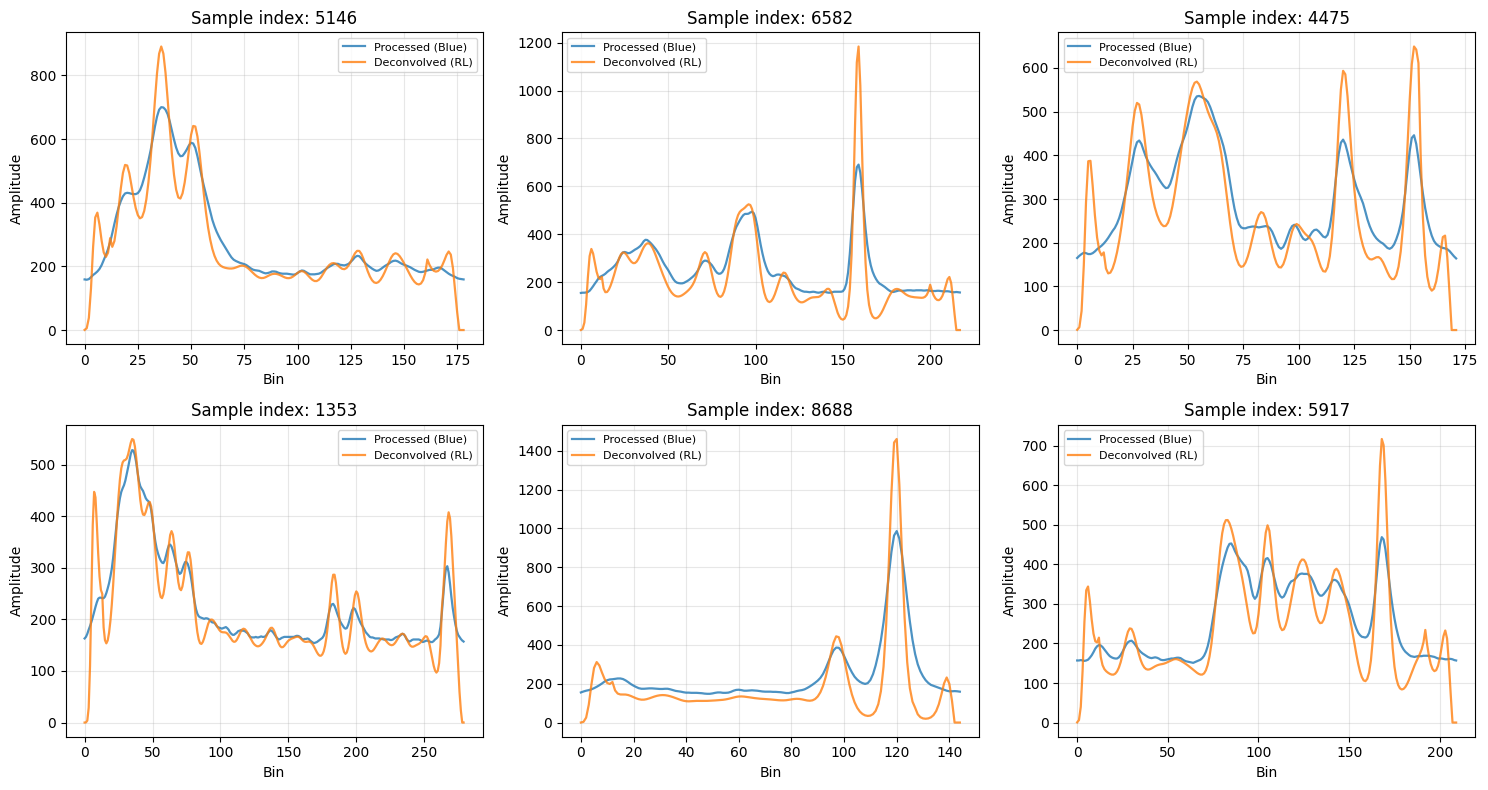

In [125]:
# Plot 6 random test waveforms overlaid with corresponding RL-deconvolved waveforms

n_plot = 6
n_available = min(len(LVIS_wf_test), len(deconvolved_rl))

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=False, sharey=False)
axes = axes.flatten()

for ax, idx in zip(axes, random_indices):
    proc_wf = LVIS_wf_test[idx][:, 1]  # waveform counts
    deconv_wf = np.asarray(deconvolved_rl[idx], dtype=float)

    # Handle any length mismatch safely
    m = min(len(proc_wf), len(deconv_wf))
    x = np.arange(m)

    ax.plot(x, proc_wf[:m], color="tab:blue", lw=1.6, alpha=0.8, label="Processed (Blue)")
    ax.plot(x, deconv_wf[:m], color="tab:orange", lw=1.6, alpha=0.8, label="Deconvolved (RL)")
    ax.set_title(f"Sample index: {idx}")
    ax.set_xlabel("Bin")
    ax.set_ylabel("Amplitude")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

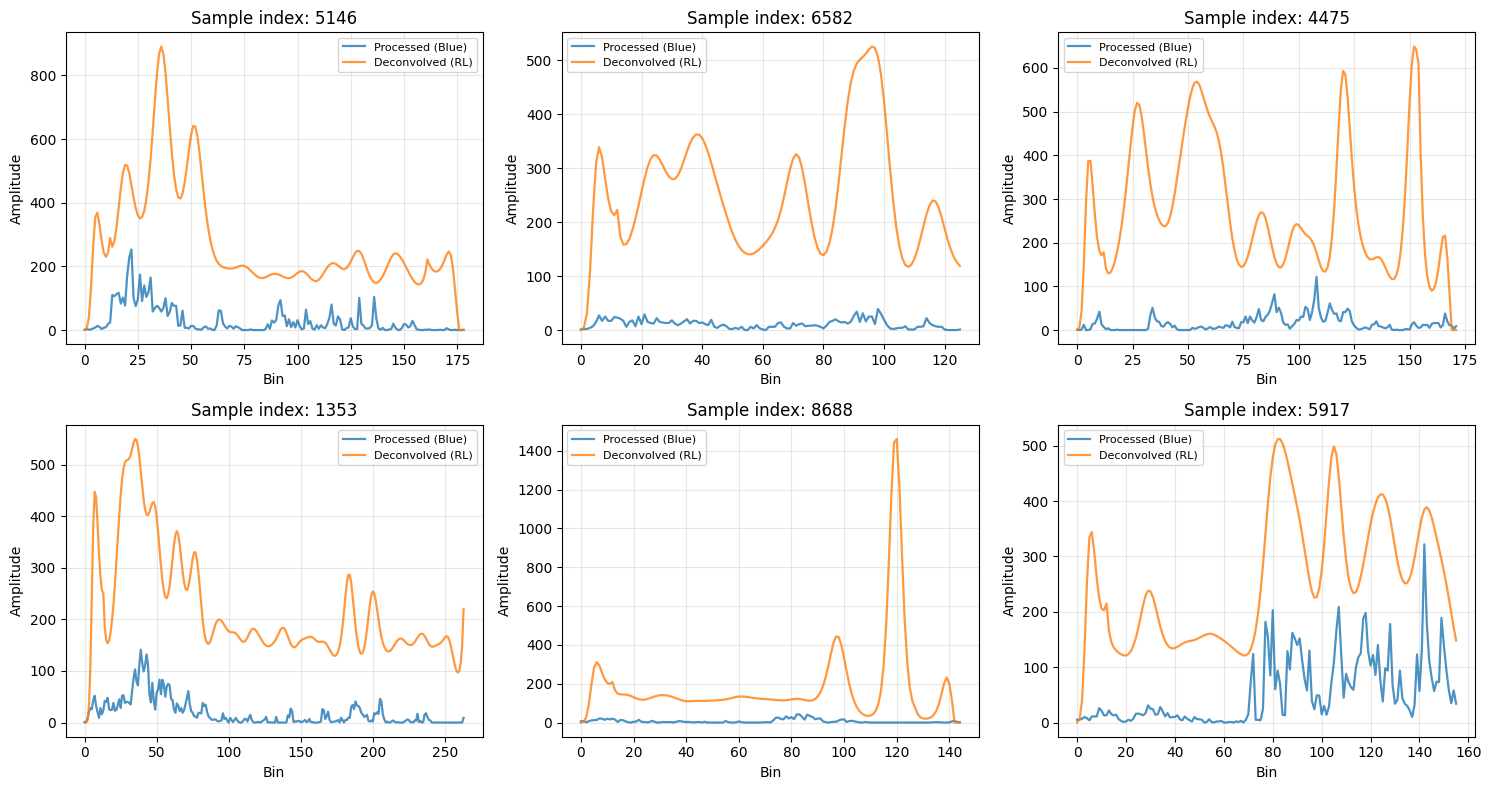

In [126]:
# Plot 6 random AOP waveforms from the test set overlaid with corresponding RL-deconvolved waveforms 

n_plot = len(random_indices)
ncols = 3
nrows = int(np.ceil(n_plot / ncols))

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=False, sharey=False)
axes = axes.flatten()

for ax, idx in zip(axes, random_indices):
    proc_wf = AOP_wf_test[idx][:, 1]  # waveform counts
    deconv_wf = np.asarray(deconvolved_rl[idx], dtype=float)

    # Handle any length mismatch safely
    m = min(len(proc_wf), len(deconv_wf))
    x = np.arange(m)

    ax.plot(x, proc_wf[:m], color="tab:blue", lw=1.6, alpha=0.8, label="Processed (Blue)")
    ax.plot(x, deconv_wf[:m], color="tab:orange", lw=1.6, alpha=0.8, label="Deconvolved (RL)")
    ax.set_title(f"Sample index: {idx}")
    ax.set_xlabel("Bin")
    ax.set_ylabel("Amplitude")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

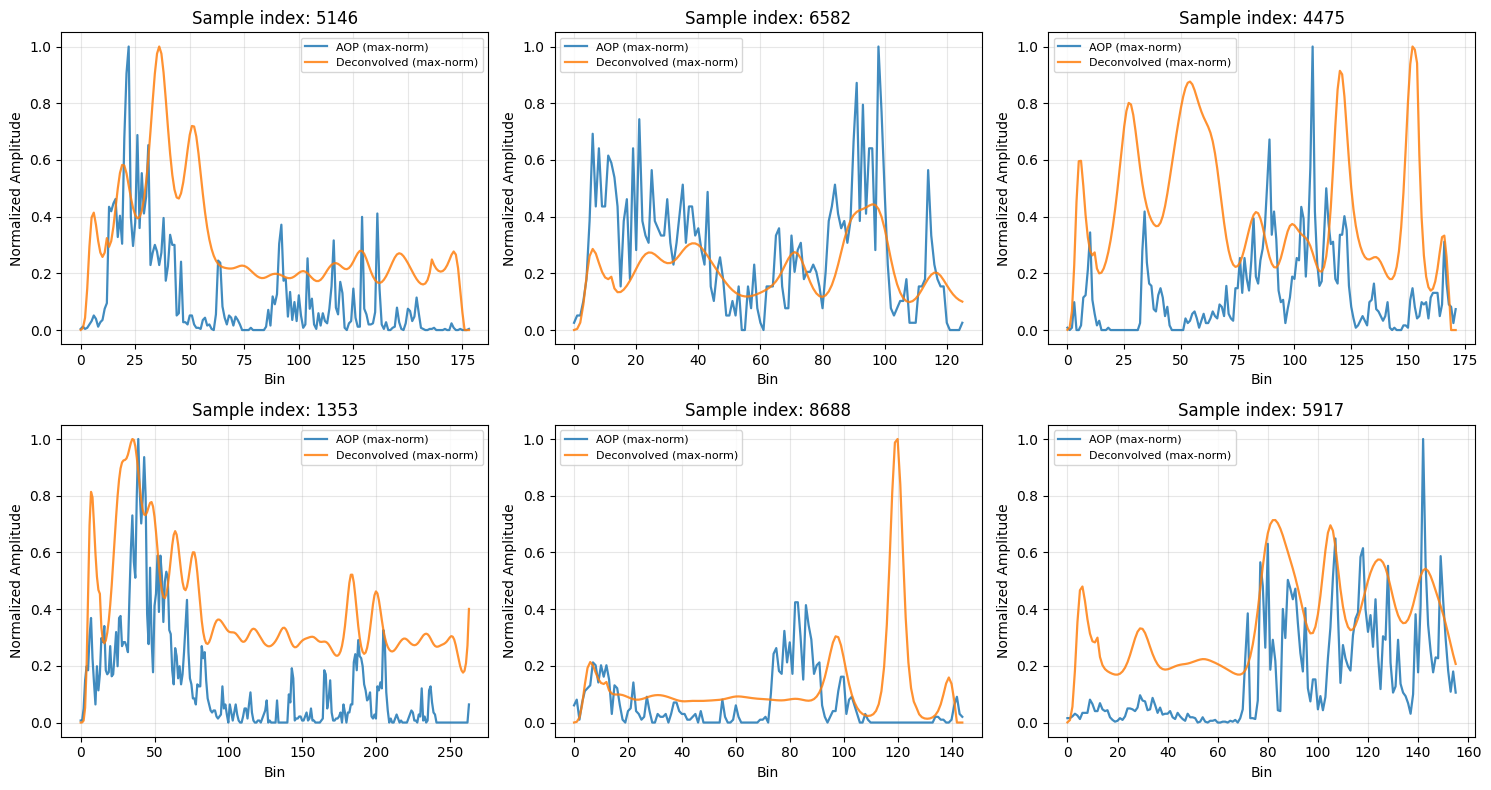

In [127]:
# Max-normalize AOP_wf_list and deconvolved_rl for selected random_indices, then plot

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=False, sharey=False)
axes = axes.flatten()

for ax, idx in zip(axes, random_indices):
    aop_wf = np.asarray(AOP_wf_test[idx][:, 1], dtype=float)
    deconv_wf = np.asarray(deconvolved_rl[idx], dtype=float)

    # Max-normalization (safe)
    aop_max = np.max(np.abs(aop_wf)) if aop_wf.size else 0.0
    deconv_max = np.max(np.abs(deconv_wf)) if deconv_wf.size else 0.0
    aop_norm = aop_wf / aop_max if aop_max > 0 else aop_wf
    deconv_norm = deconv_wf / deconv_max if deconv_max > 0 else deconv_wf

    # Handle length mismatch
    m = min(len(aop_norm), len(deconv_norm))
    x = np.arange(m)

    ax.plot(x, aop_norm[:m], color="tab:blue", lw=1.6, alpha=0.85, label="AOP (max-norm)")
    ax.plot(x, deconv_norm[:m], color="tab:orange", lw=1.6, alpha=0.85, label="Deconvolved (max-norm)")
    ax.set_title(f"Sample index: {idx}")
    ax.set_xlabel("Bin")
    ax.set_ylabel("Normalized Amplitude")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

Compare LVIS-RL_deconvolved correlation with AOP-Gold_deconvolved normalized correlation:

In [128]:
# Concatenate all waveforms in LVIS_wf_test and Deconvolved_rl for correlation and RMSE calculation
lvis_counts_all = np.concatenate(LVIS_wf_test)[:, 1]  # Get counts from all LVIS waveforms
deconv_counts_all = np.concatenate(deconvolved_rl)  # Deconvolved waveforms are already counts-like

# Compute metrics
corr = np.corrcoef(lvis_counts_all, deconv_counts_all)[0, 1]
rmse = np.sqrt(np.mean((lvis_counts_all - deconv_counts_all) ** 2))

print(f"LVIS vs Deconvolved metrics:")
print(f"  Correlation: {corr:.4f}")
print(f"  RMSE: {rmse:.4f}")

LVIS vs Deconvolved metrics:
  Correlation: 0.9094
  RMSE: 74.4577


In [129]:
# Compute correlation between RL-deconvolved waveforms and AOP waveforms
metrics_deconv_aop = compute_lvis_aop_metrics(LVIS_wf_test, AOP_wf_test, Deconvolved_list=deconvolved_rl)

10111it [00:04, 2423.25it/s]


LVIS vs AOP metrics:
  Correlation: 0.5950
  RMSE: 158.9279
  Normalized correlation: 0.7210
  Normalized RMSE: 0.1445
  R²: -90.9963
  MAE: 73.8709


Compare CSC metric correlation between LVIS-AOP and Deconvolved-AOP:

In [18]:
def get_FHD(wf, idx, bin_width=1.0, Deconvolved_list=None):
    """
    Compute FHD (Shannon index) for a waveform array.
    wf: Nx2 array-like where col0=heights, col1=counts
    bin_width: width of height bins (default 1.0 m)
    Returns: FHD (float)
    """
    wf = np.asarray(wf)
    if wf.size == 0:
        return 0.0

    # Bin LVIS counts to grid
    if Deconvolved_list is not None:
        heights = wf[:, 0].astype(float)
        counts = Deconvolved_list[idx].astype(float)  # Use deconvolved counts instead of original LVIS counts
    else:
        heights = wf[:, 0].astype(float)
        counts = wf[:, 1].astype(float)

    # ensure heights ascending for digitize
    sort_idx = np.argsort(heights)
    heights = heights[sort_idx]
    counts = counts[sort_idx]

    # make bin edges from floor(min) to ceil(max) with step bin_width
    bin_edges = np.arange(np.floor(heights.min()),
                          np.ceil(heights.max()) + bin_width,
                          bin_width)

    # digitize and aggregate
    bin_idx = np.digitize(heights, bin_edges) - 1
    binned_counts = np.zeros(max(0, len(bin_edges) - 1))
    for i in range(len(binned_counts)):
        mask = (bin_idx == i)
        if mask.any():
            binned_counts[i] = counts[mask].sum()

    # keep same ordering as your original cell
    binned_counts = binned_counts[::-1]

    # Shannon index (ignore zero bins)
    nz = binned_counts[binned_counts > 0]
    if nz.size == 0:
        return 0.0
    p = nz / nz.sum()
    return -np.sum(p * np.log(p))

def get_VCR(wf, idx, Deconvolved_list=None):
    """
    Compute variance (StdBin) of heights weighted by counts for a waveform array.
    wf: Nx2 array-like where column 0 = heights, column 1 = counts.
    Returns: StdBin (float)
    """
    if Deconvolved_list is not None:
        counts = Deconvolved_list[idx].astype(float)  # Use deconvolved counts instead of original LVIS counts
        heights = wf[:, 0].astype(float)
    else:
        counts = wf[:, 1].astype(float)
        heights = wf[:, 0].astype(float)

    total_counts = counts.sum()
    if total_counts == 0:
        normalized_counts = counts  # all zeros -> variance zero
    else:
        normalized_counts = counts / total_counts

    H_x = (heights * normalized_counts).sum()
    StdBin = (normalized_counts * (heights - H_x) ** 2).sum()

    return StdBin

In [19]:
# Lists to store FHD and VCR values
LVIS_FHD_list, LVIS_VCR_list = [], []
AOP_FHD_list, AOP_VCR_list = [], []
Gold_FHD_list, Gold_VCR_list = [], []
RL_FHD_list, RL_VCR_list = [], []

# Compute metrics for LVIS test waveforms
for i, wf in tqdm(enumerate(LVIS_wf_test)):
    LVIS_FHD_list.append(get_FHD(wf, i))
    LVIS_VCR_list.append(get_VCR(wf, i))

# Compute metrics for Gold-deconvolved waveforms
for i, wf in tqdm(enumerate(LVIS_wf_test)):
    Gold_FHD_list.append(get_FHD(wf, i, Deconvolved_list=deconvolved_gold))
    Gold_VCR_list.append(get_VCR(wf, i, Deconvolved_list=deconvolved_gold))

# Compute metrics for RL-deconvolved waveforms
for i, wf in tqdm(enumerate(LVIS_wf_test)):
    RL_FHD_list.append(get_FHD(wf, i, Deconvolved_list=deconvolved_rl))
    RL_VCR_list.append(get_VCR(wf, i, Deconvolved_list=deconvolved_rl))

# Compute metrics for AOP test waveforms
for i, wf in tqdm(enumerate(AOP_wf_test)):
    AOP_FHD_list.append(get_FHD(wf, i))
    AOP_VCR_list.append(get_VCR(wf, i))

print("LVIS FHD length:", len(LVIS_FHD_list))
print("LVIS VCR length:", len(LVIS_VCR_list))
print("Gold FHD length:", len(Gold_FHD_list))
print("Gold VCR length:", len(Gold_VCR_list))
print("RL FHD length:", len(RL_FHD_list))
print("RL VCR length:", len(RL_VCR_list))
print("AOP FHD length:", len(AOP_FHD_list))
print("AOP VCR length:", len(AOP_VCR_list))

10111it [00:01, 7707.02it/s]
10111it [00:01, 7593.84it/s]
10111it [00:01, 7663.75it/s]
10111it [00:01, 8227.57it/s]

LVIS FHD length: 10111
LVIS VCR length: 10111
Gold FHD length: 10111
Gold VCR length: 10111
RL FHD length: 10111
RL VCR length: 10111
AOP FHD length: 10111
AOP VCR length: 10111


In [20]:
# CSC correlation with LVIS baseline
VCR_corr = np.corrcoef(AOP_VCR_list, LVIS_VCR_list)[0, 1]
VCR_rmse = np.sqrt(np.mean((np.array(AOP_VCR_list) - np.array(LVIS_VCR_list)) ** 2))
FHD_corr = np.corrcoef(AOP_FHD_list, LVIS_FHD_list)[0, 1]
FHD_rmse = np.sqrt(np.mean((np.array(AOP_FHD_list) - np.array(LVIS_FHD_list)) ** 2))

print(f"LVIS baseline metrics correlation with AOP:")
print(f"  VCR correlation: {VCR_corr:.4f}")
print(f"  VCR RMSE: {VCR_rmse:.4f}")
print(f"  FHD correlation: {FHD_corr:.4f}")
print(f"  FHD RMSE: {FHD_rmse:.4f}")

# CSC correlation with Gold-deconvolved waveforms
VCR_corr_gold = np.corrcoef(AOP_VCR_list, Gold_VCR_list)[0, 1]
VCR_rmse_gold = np.sqrt(np.mean((np.array(AOP_VCR_list) - np.array(Gold_VCR_list)) ** 2))
FHD_corr_gold = np.corrcoef(AOP_FHD_list, Gold_FHD_list)[0, 1]
FHD_rmse_gold = np.sqrt(np.mean((np.array(AOP_FHD_list) - np.array(Gold_FHD_list)) ** 2))

print(f"Gold-deconvolved metrics correlation with AOP:")
print(f"  VCR correlation: {VCR_corr_gold:.4f}")
print(f"  VCR RMSE: {VCR_rmse_gold:.4f}")
print(f"  FHD correlation: {FHD_corr_gold:.4f}")
print(f"  FHD RMSE: {FHD_rmse_gold:.4f}")

# CSC correlation with RL-deconvolved waveforms
VCR_corr_rl = np.corrcoef(AOP_VCR_list, RL_VCR_list)[0, 1]
VCR_rmse_rl = np.sqrt(np.mean((np.array(AOP_VCR_list) - np.array(RL_VCR_list)) ** 2))
FHD_corr_rl = np.corrcoef(AOP_FHD_list, RL_FHD_list)[0, 1]
FHD_rmse_rl = np.sqrt(np.mean((np.array(AOP_FHD_list) - np.array(RL_FHD_list)) ** 2))

print(f"RL-deconvolved metrics correlation with AOP:")
print(f"  VCR correlation: {VCR_corr_rl:.4f}")
print(f"  VCR RMSE: {VCR_rmse_rl:.4f}")
print(f"  FHD correlation: {FHD_corr_rl:.4f}")
print(f"  FHD RMSE: {FHD_rmse_rl:.4f}")

LVIS baseline metrics correlation with AOP:
  VCR correlation: 0.6206
  VCR RMSE: 49.8472
  FHD correlation: 0.7362
  FHD RMSE: 0.6549
Gold-deconvolved metrics correlation with AOP:
  VCR correlation: 0.6202
  VCR RMSE: 50.6620
  FHD correlation: 0.7298
  FHD RMSE: 0.5675
RL-deconvolved metrics correlation with AOP:
  VCR correlation: 0.6205
  VCR RMSE: 49.2546
  FHD correlation: 0.7414
  FHD RMSE: 0.5797


In [138]:
# CSC correlation with LVIS baseline
VCR_corr = np.corrcoef(AOP_VCR_list, LVIS_VCR_list)[0, 1]
FHD_corr = np.corrcoef(AOP_FHD_list, LVIS_FHD_list)[0, 1]

print(f"LVIS baseline metrics correlation with AOP:")
print(f"  VCR correlation: {VCR_corr:.4f}")
print(f"  FHD correlation: {FHD_corr:.4f}")

# CSC correlation with Gold-deconvolved waveforms
VCR_corr_gold = np.corrcoef(AOP_VCR_list, Gold_VCR_list)[0, 1]
FHD_corr_gold = np.corrcoef(AOP_FHD_list, Gold_FHD_list)[0, 1]

print(f"Gold-deconvolved metrics correlation with AOP:")
print(f"  VCR correlation: {VCR_corr_gold:.4f}")
print(f"  FHD correlation: {FHD_corr_gold:.4f}")

# CSC correlation with RL-deconvolved waveforms
VCR_corr_rl = np.corrcoef(AOP_VCR_list, RL_VCR_list)[0, 1]
FHD_corr_rl = np.corrcoef(AOP_FHD_list, RL_FHD_list)[0, 1]

print(f"RL-deconvolved metrics correlation with AOP:")
print(f"  VCR correlation: {VCR_corr_rl:.4f}")
print(f"  FHD correlation: {FHD_corr_rl:.4f}")

LVIS baseline metrics correlation with AOP:
  VCR correlation: 0.6206
  FHD correlation: 0.7362
Gold-deconvolved metrics correlation with AOP:
  VCR correlation: 0.6204
  FHD correlation: 0.7299
RL-deconvolved metrics correlation with AOP:
  VCR correlation: 0.6205
  FHD correlation: 0.7395
